In [1]:
# !pip install diffusers["torch"] transformers datasets accelerate
!nvidia-smi

Tue Apr 29 20:26:11 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 570.124.06             Driver Version: 570.124.06     CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX 6000 Ada Gene...    Off |   00000000:01:00.0 Off |                    0 |
| 30%   30C    P8             26W /  300W |   31119MiB /  46068MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
from torchvision import transforms
from torchvision.transforms import Lambda

image_size = 64  # Adjust based on your requirements
transform = transforms.Compose([
    # transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Resize((image_size, image_size)),
    Lambda(lambda x: x * 2 - 1)
])

reverse_transform = transforms.Compose([
    transforms.ToTensor(),
    Lambda(lambda x: (x + 1) / 2),
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((image_size, image_size)),
    transforms.ToPILImage()
])

In [3]:
import torch
from diffusers import UNet2DModel, DDPMScheduler

in_channels = 4
out_channels = 1

model = UNet2DModel(
    sample_size=image_size,
    in_channels=in_channels,
    out_channels=out_channels,
    layers_per_block=2,
    block_out_channels=(32, 64, 128, 256, 512, 1024),
    down_block_types=(
        "AttnDownBlock2D",  # a regular ResNet downsampling block
        "AttnDownBlock2D",
        "AttnDownBlock2D",
        "AttnDownBlock2D",
        "AttnDownBlock2D",
        "AttnDownBlock2D",
    ),
    up_block_types=(
        "AttnUpBlock2D",  # a regular ResNet upsampling block
        "AttnUpBlock2D",
        "AttnUpBlock2D",
        "AttnUpBlock2D",
        "AttnUpBlock2D",
        "AttnUpBlock2D",
    ),
)

noise_scheduler = DDPMScheduler(num_train_timesteps=100, beta_schedule='squaredcos_cap_v2')

In [4]:
device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")

In [5]:
from torch.utils.data import Dataset
import os
import numpy as np
import random
from tqdm import tqdm

class CustomDataset(Dataset):
    def __init__(self, folder_paths, transform=transform):
        # self.folder_path = folder_path
        self.image_paths = []
        for folder_path in folder_paths:
            self.image_paths.extend([os.path.join(folder_path, f) for f in os.listdir(folder_path)])
        random.shuffle(self.image_paths)
        self.image_paths = self.image_paths
        self.final_image_paths = []
        for idx in tqdm(range(len(self.image_paths))):
            file = self.image_paths[idx]
            npz_file = np.load(file)
            object_mask = npz_file['object_mask']
            
            if np.sum(object_mask) == 0:
                continue
            self.final_image_paths.append(file)
        self.final_image_paths = self.final_image_paths
        self.transform = transform

    def __len__(self):
        return len(self.final_image_paths)

    def __getitem__(self, index):
        image_path = self.final_image_paths[index]
        npz_file = np.load(image_path)
        object_mask = npz_file['object_mask']
        goal_mask = npz_file['goal_mask']
        scene = npz_file['scene']
        image = np.concatenate([scene, object_mask, goal_mask], axis=-1)
        image = self.transform(image)
        return image

data_folder = ['/common/users/dm1487/namo_data/images/apr28/fixed_start_fixed_goal_many_env_1_example']
dataset = CustomDataset(folder_paths=data_folder, transform=transform)
print(len(dataset))

100%|██████████| 34/34 [00:00<00:00, 1021.95it/s]

24


In [6]:
dataset[0].shape

torch.Size([5, 64, 64])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0000005].


23


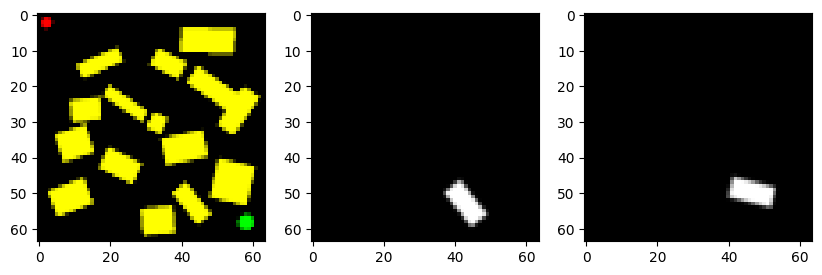

In [47]:
from matplotlib import pyplot as plt
rand_idx = 23 # np.random.randint(0, len(dataset))
print(rand_idx)
fig, axs = plt.subplots(1, 3, figsize=(10, 5))
axs[0].imshow(dataset[rand_idx][:3].permute(1, 2, 0).numpy())
axs[1].imshow(dataset[rand_idx][3:4].permute(1, 2, 0).numpy(), cmap='gray')
axs[2].imshow(dataset[rand_idx][4:5].permute(1, 2, 0).numpy(), cmap='gray')
plt.show()


In [8]:
from torch.utils.data import DataLoader
from torch.optim import AdamW
import torch.nn.functional as F
from accelerate import Accelerator
from tqdm import tqdm
import torch


torch.cuda.set_device(1)

# Initialize Accelerator
accelerator = Accelerator(device_placement=True)
# accelerator.device = device
model.train()
# DataLoader
train_dataloader = DataLoader(dataset, batch_size=16, shuffle=True)

# Optimizer
last_lr = 1e-4
optimizer = AdamW(model.parameters(), lr=last_lr)

num_epochs = 100
# scheduler
# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=30, verbose=True)

# Prepare for distributed training
model, optimizer, train_dataloader = accelerator.prepare(model, optimizer, train_dataloader)

model_output_dir = 'saved_diffusion_models'
if not os.path.exists(model_output_dir):
    os.makedirs(model_output_dir)

# Training loop
for epoch in range(num_epochs):
    epoch_loss = 0
    pbar = tqdm(total=len(train_dataloader), desc=f"Epoch {epoch+1}/{num_epochs}")
    
    for step, batch in enumerate(train_dataloader):
        optimizer.zero_grad()
        clean_images = batch
        noise = torch.randn(clean_images.shape).to(clean_images.device)
        timesteps = torch.randint(0, noise_scheduler.config.num_train_timesteps, (clean_images.shape[0],), device=clean_images.device).long()
        noisy_images = noise_scheduler.add_noise(clean_images[:, -out_channels:, :, :], noise[:, -out_channels:, :, :], timesteps)
        clean_images[:, -out_channels:, :, :] = noisy_images
        noise_pred = model(clean_images, timesteps).sample
        loss = F.mse_loss(noise_pred, noise[:, -out_channels:, :, :])
        accelerator.backward(loss)
        optimizer.step()
        epoch_loss += loss.item()
        pbar.update(1)
    pbar.close()
    # scheduler.step(epoch_loss / len(train_dataloader))
    # if scheduler.get_last_lr()[0] < last_lr:
    #     last_lr = scheduler.get_last_lr()
    #     print("changed LR to ", last_lr)
    print(f"Epoch {epoch}, Loss: {epoch_loss / len(train_dataloader)}")
    
    if epoch % 10 == 0:
        accelerator.wait_for_everyone()
        if accelerator.is_main_process:
            unwrapped_model = accelerator.unwrap_model(model)
            unwrapped_model.save_pretrained(model_output_dir)
            noise_scheduler.save_pretrained(model_output_dir)
accelerator.wait_for_everyone()
if accelerator.is_main_process:
    unwrapped_model = accelerator.unwrap_model(model)
    unwrapped_model.save_pretrained(model_output_dir)
    noise_scheduler.save_pretrained(model_output_dir)
    

Epoch 1/100: 100%|██████████| 97/97 [00:59<00:00,  1.63it/s]


Epoch 0, Loss: 0.2362686054224206


Epoch 2/100: 100%|██████████| 97/97 [00:58<00:00,  1.67it/s]


Epoch 1, Loss: 0.0613732708368412


Epoch 3/100: 100%|██████████| 97/97 [00:55<00:00,  1.75it/s]


...

Epoch 97, Loss: 0.0016573186202896472


Epoch 99/100: 100%|██████████| 97/97 [00:58<00:00,  1.67it/s]


Epoch 98, Loss: 0.001940102030201479


Epoch 100/100: 100%|██████████| 97/97 [00:55<00:00,  1.75it/s]


Epoch 99, Loss: 0.0012663708394873388


In [9]:
model = UNet2DModel.from_pretrained(model_output_dir, device_map={"": "cuda:1"})
noise_scheduler = DDPMScheduler.from_pretrained(model_output_dir, device_map={"": "cuda:1"})
# model.eval()
# noise_scheduler.eval()
# model = model.to("cuda:1")

In [42]:
from tqdm import tqdm
from diffusers import DPMSolverMultistepScheduler

model.eval()
# img_idx = 1


# with original DPM solver
num_images = 64
clean_images = dataset[img_idx].unsqueeze(0)
clean_images = clean_images.repeat(num_images, 1, 1, 1)
clean_images = clean_images.to("cuda")
img = clean_images.clone()
noise = torch.randn(img.shape).to(img)
img[:, -out_channels:, :, :] = noise[:, -out_channels:, :, :]
with torch.no_grad():
    for t in tqdm(noise_scheduler.timesteps):
        noise_pred = model(img, t).sample
        img[:, -out_channels:, :, :] = noise_scheduler.step(noise_pred, t, img[:, -out_channels:, :, :]).prev_sample
final_predictions = (img[:, -out_channels:, :, :].clone().cpu().numpy())

# clean_images = dataset[img_idx].unsqueeze(0)
# clean_images = clean_images.repeat(num_images, 1, 1, 1)
# clean_images = clean_images.to("cuda")
# img = clean_images.clone()
# img[:, -out_channels:, :, :] = noise[:, -out_channels:, :, :]
# # with faster DPM solver
# faster_noise_scheduler = DPMSolverMultistepScheduler(
#     num_train_timesteps=noise_scheduler.config.num_train_timesteps,
#     beta_start=0.0001,
#     beta_end=0.02,
#     beta_schedule='linear',
#     solver_order=3,            # Order of the solver; 2 is recommended for guided sampling
#     prediction_type='epsilon', # Type of prediction ('epsilon' for noise prediction models)
#     algorithm_type='dpmsolver++' # Algorithm type; 'dpmsolver++' is recommended
# )
# faster_noise_scheduler.set_timesteps(20, device='cuda')
# with torch.no_grad():
#     # clean_images = dataset[img_idx].unsqueeze(0)
#     # clean_images = clean_images.repeat(num_images, 1, 1, 1)
#     # clean_images = clean_images.to("cuda")
#     # img = clean_images.clone()
#     # noise = torch.randn(img.shape).to(img)
#     for t in tqdm(faster_noise_scheduler.timesteps):
#         noise_pred = model(img, t).sample
#         img[:, -out_channels:, :, :] = faster_noise_scheduler.step(noise_pred, t, img[:, -out_channels:, :, :]).prev_sample
# final_predictions_faster = (img[:, -out_channels:, :, :].clone().cpu().numpy())

100%|██████████| 100/100 [00:21<00:00,  4.70it/s]


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0000005].


809


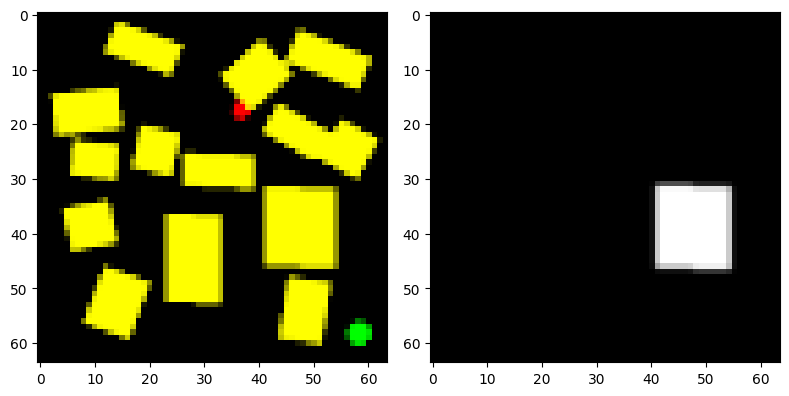

In [41]:
img_idx = np.random.randint(len(dataset))
print(img_idx)
clean_image = dataset[img_idx]
# plt.imshow(clean_images)
# plt.axis('off')
from matplotlib import pyplot as plt
fig, axs = plt.subplots(1, 2, figsize=(8, 4))
axs[0].imshow(clean_image[:3, :, :].permute(1, 2, 0).numpy(), cmap='gray')
axs[1].imshow(clean_image[3:4, :, :].permute(1, 2, 0).numpy(), cmap='gray')
plt.tight_layout()
plt.show()

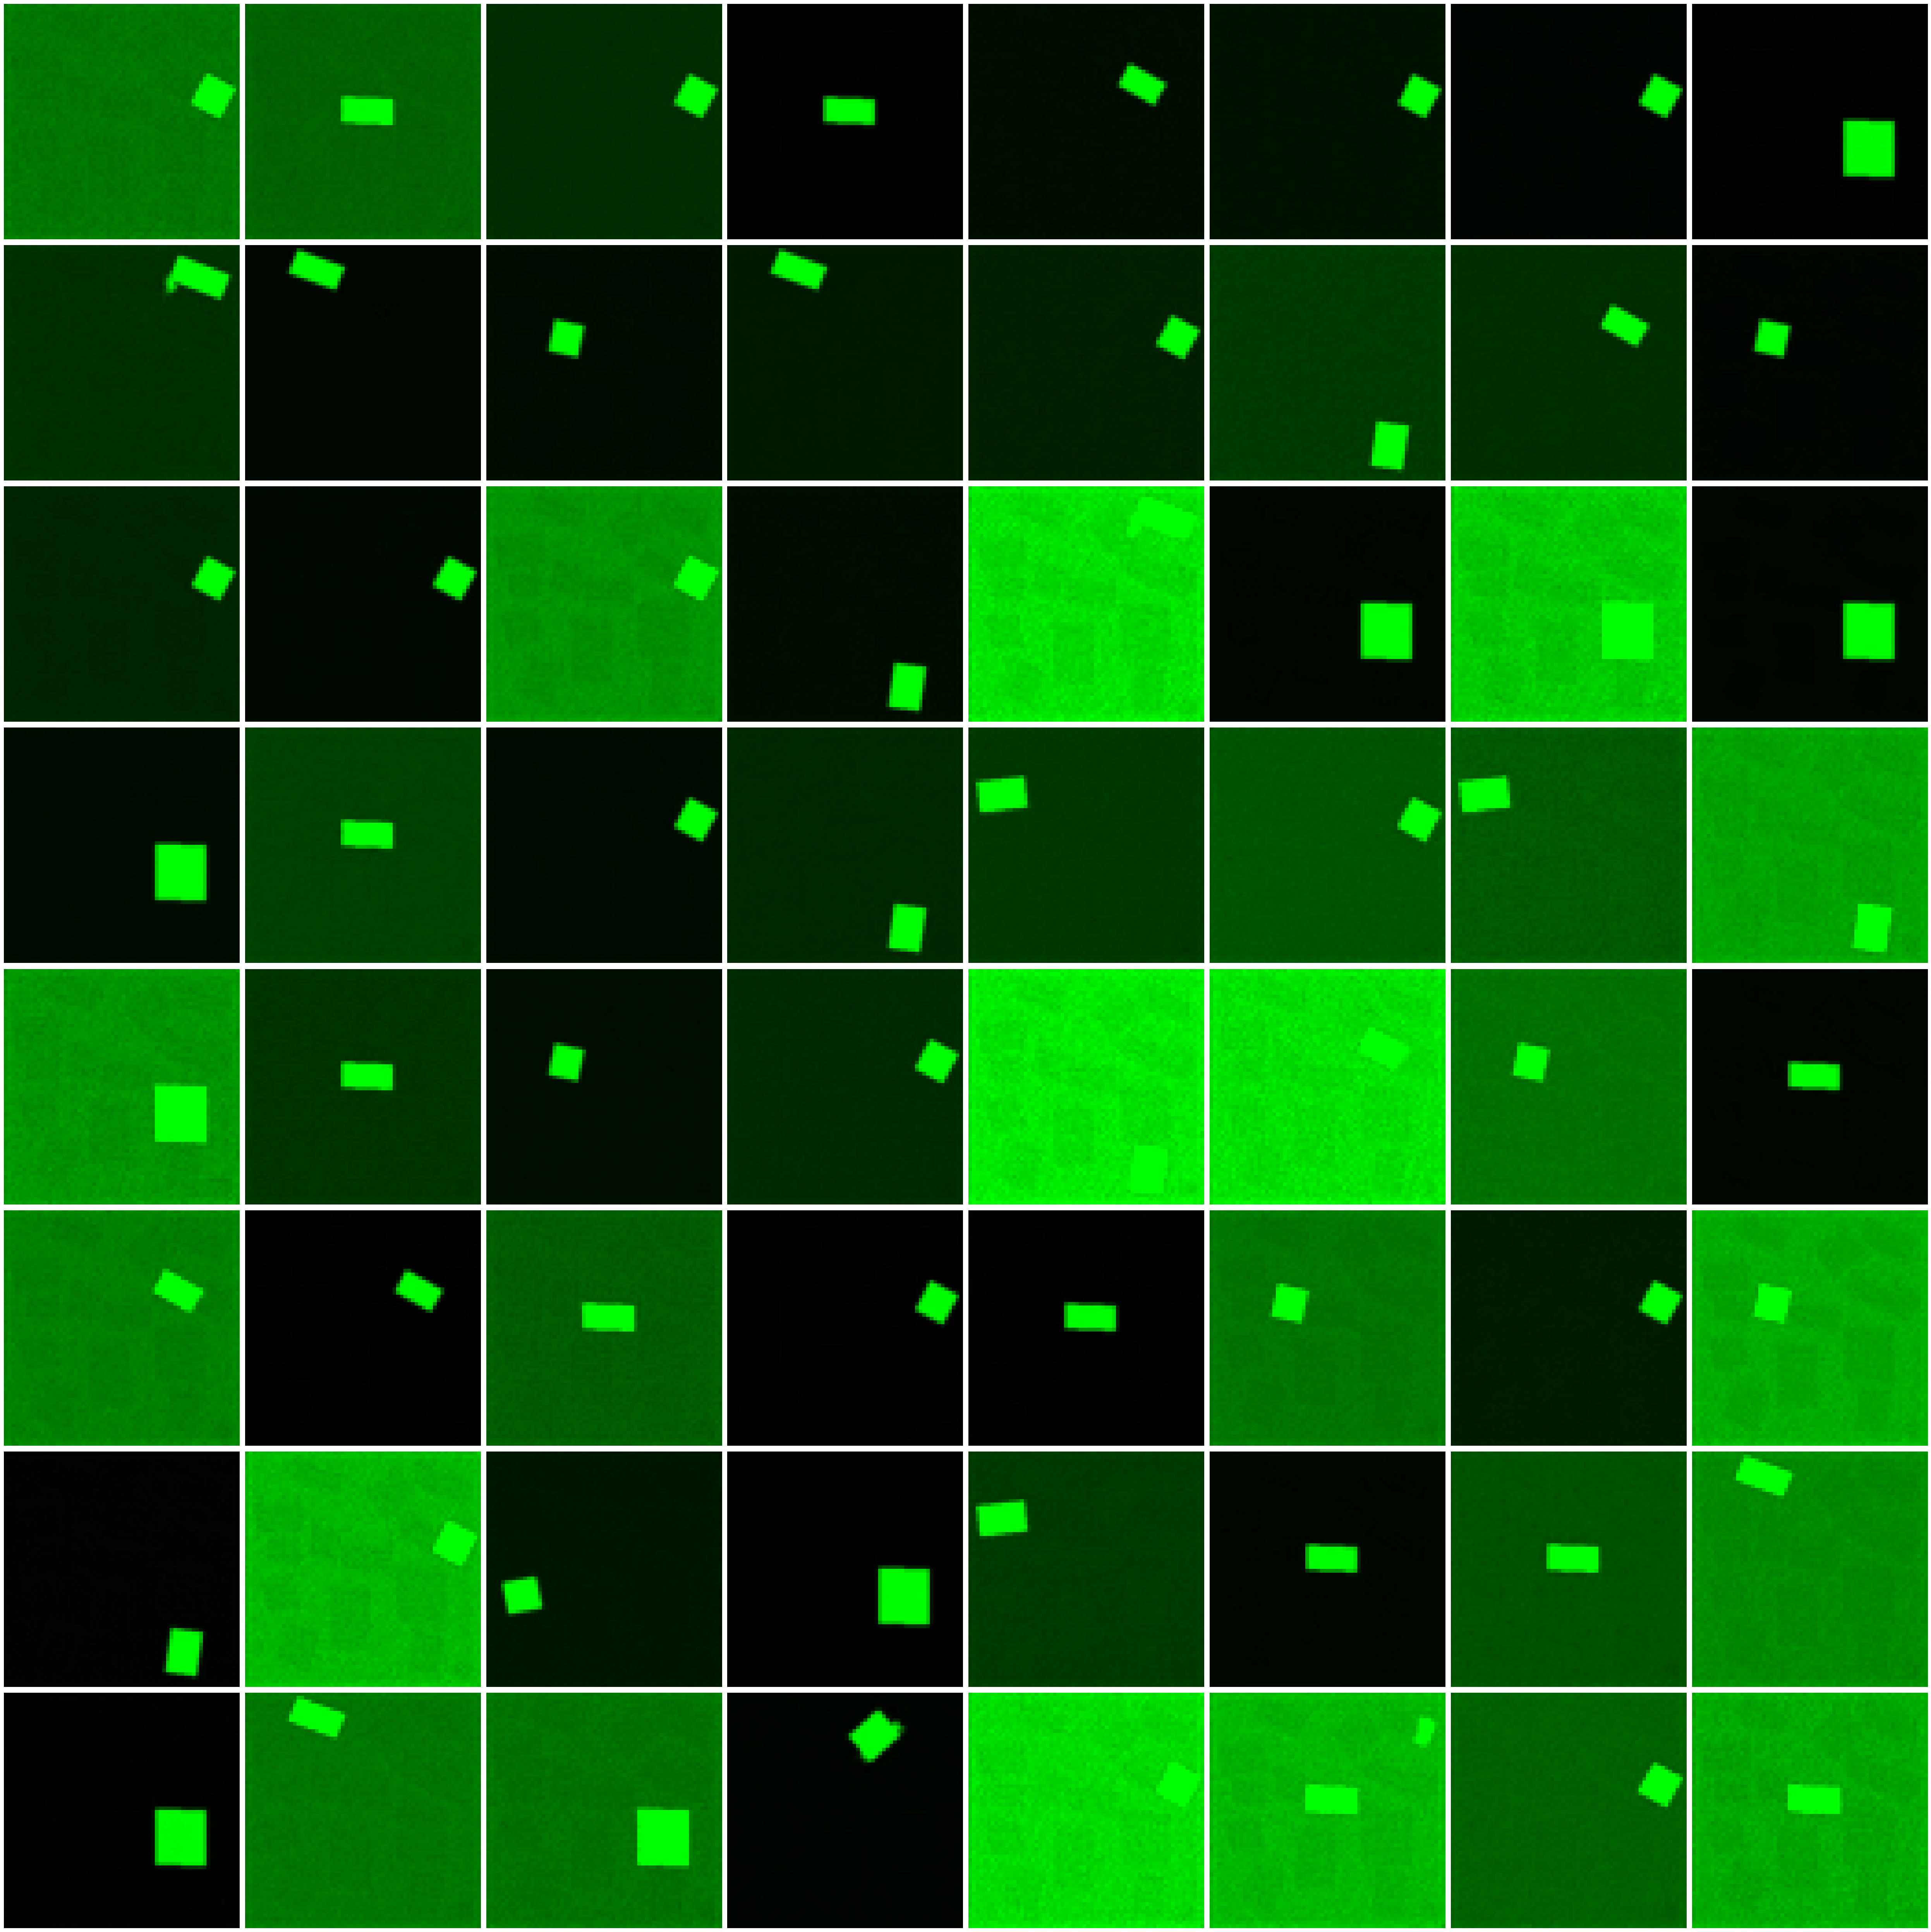

In [43]:
from matplotlib import pyplot as plt
# plt.imshow(np.array(generated_images[1]))
fig, axs = plt.subplots(8, 8, figsize=(50, 50))
axs = axs.flatten()
for i, ax in enumerate(axs):
    new_img = np.zeros((image_size, image_size, 3))
    # new_img[:, :, 1] = (clean_image[3, :, :].numpy() + 1) / 2.0
    new_img[:, :, 1] = ((final_predictions[i, 0] + 1)/2.0)
    # new_img[:, :, 2] = ((final_predictions_faster[i, 0] + 1)/2.0)
    ax.imshow(new_img)
    ax.axis('off')
plt.tight_layout()
plt.show()

In [44]:
import cv2
def get_labels(binary_mask):
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(binary_mask)
    masks = []
    for i in range(num_labels):
        area = stats[i, cv2.CC_STAT_AREA]
        instance_mask = (labels == i).astype(np.uint8)
        masks.append(instance_mask)
    if len(masks) > 1:
        return num_labels, masks, area
    else:
        return None, None, None
    
def extract_se2_pose(mask):
    # 1. Centroid
    M = cv2.moments(mask.astype(np.uint8))
    if M["m00"] == 0:
        return None
    cx = M["m10"] / M["m00"]
    cy = M["m01"] / M["m00"]
    
    # # 2. Orientation (θ) using PCA
    ys, xs = np.nonzero(mask)
    coords = np.vstack([xs, ys]).astype(np.float32)
    mean = np.mean(coords, axis=1, keepdims=True)
    centered = coords - mean
    cov = centered @ centered.T
    eigvals, eigvecs = np.linalg.eigh(cov)
    principal_axis = eigvecs[:, np.argmax(eigvals)]
    theta = np.arctan2(principal_axis[1], principal_axis[0])
    return np.array([cx, cy, theta])

In [45]:
from tqdm import tqdm
threshold = 0.9
predicted_poses_masks = {}
for i in tqdm(range(final_predictions.shape[0])):
    binary_mask = (final_predictions[i, 0] > threshold).astype(np.uint8)
    num_labels, seg_mask, area = get_labels(binary_mask)
    if num_labels == 2:
        predicted_poses_masks[i] = (extract_se2_pose(seg_mask[1]), seg_mask[1])
        
'valid ' + str(len(predicted_poses_masks.keys())) + '/' + str(final_predictions.shape[0]) + ' predicted masks'

100%|██████████| 64/64 [00:00<00:00, 1661.91it/s]


'valid 59/64 predicted masks'

In [46]:
# clean_img = clean_image.clone().numpy()[:3, :, :].transpose(1, 2, 0)
# print(clean_img.shape)
# print(clean_img.shape, masks[1].shape)
# clean_img[:, :, :1] = clean_img[:, :, :1] * masks[1][:, :, np.newaxis]
# plt.imshow(clean_img)
# plt.show()

In [47]:
# convert rgb to gray
counter = {}

dist_func = lambda x, y: np.linalg.norm(x - y, axis=-1)
clean_img = clean_image.clone().numpy()[:3, :, :].transpose(1, 2, 0)
clean_img = cv2.cvtColor(clean_img, cv2.COLOR_RGB2GRAY)
binary_mask = (clean_img > 0.5).astype(np.uint8)
num_labels, original_masks, area = get_labels(binary_mask)
min_idx = None
min_dist = np.inf
original_poses_masks = {}
for i in range(1, num_labels):
   original_poses_masks[i] = (extract_se2_pose(original_masks[i]), original_masks[i])

In [48]:
# each predicted mask in predicted_poses_masks should be matched to the closest original_poses_masks and count the number of correct matches
from collections import Counter
count = Counter()
for i in predicted_poses_masks.keys():
    predicted_pose, predicted_mask = predicted_poses_masks[i]
    min_dist = np.inf
    min_idx = None
    for j in original_poses_masks.keys():
        original_pose, original_mask = original_poses_masks[j]
        dist = dist_func(predicted_pose[:2], original_pose[:2])
        if dist < min_dist:
            min_dist = dist
            min_idx = j
    count[min_idx] += 1
print(count)

Counter({4: 19, 7: 10, 8: 9, 5: 6, 12: 5, 1: 4, 3: 3, 2: 2, 9: 1})


{4: 0.3220338983050847,
 7: 0.1694915254237288,
 8: 0.15254237288135594,
 2: 0.03389830508474576,
 1: 0.06779661016949153,
 5: 0.1016949152542373,
 12: 0.0847457627118644,
 3: 0.05084745762711865,
 9: 0.01694915254237288}

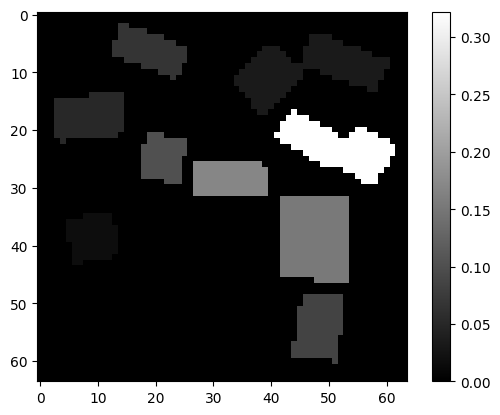

In [49]:
total_sum = 0
for k, v in count.items():
    total_sum += v
dist = {}
probs = np.zeros(50)
for k, v in count.items():
    dist[k] = v/total_sum
    probs[k] = v/total_sum
heatmap_img = np.zeros((image_size, image_size))

for k, v in dist.items():
    heatmap_img += original_poses_masks[k][1] * v
# plt.imshow(original_poses_masks[count.most_common(10)[2][0]][1], cmap='gray')
plt.imshow(heatmap_img, cmap='gray')
plt.colorbar()
dist


In [179]:
l = []
for i in range(1000):
    l.append(np.random.choice(range(50), p=probs))
new_ctr = Counter(l)
new_ctr


Counter({np.int64(1): 997, np.int64(6): 3})

In [4]:

from glob import glob
import os
import numpy as np
data_folders = ['/common/users/dm1487/namo_data/fresh_apr14/env_config_1']
data_files = []
for data_folder in data_folders:
    data_files.extend(glob(os.path.join(data_folder, '*.json')))
    
print(len(data_files))
# data_files = data_files[:10]


940


In [127]:
import json
from tqdm import tqdm
points = []
actions = []
all_data = []
for data_file in tqdm(data_files):
    with open(data_file, 'r') as f:
        data = json.load(f)
    for dp_idx, dp in enumerate(data['data_points']):
        if dp_idx == 0:
            continue
        point = []
        if 'action' in dp:
            point.extend(dp['state']['robot']['position'][:2])
            for obj_name, obj_state in dp['state']['objects'].items():
                point.extend(obj_state['position'][:2])
            points.append(point)
            actions.append(dp['action']['object_name'])
            all_data.append(dp)
points = np.array(points)

100%|██████████| 940/940 [00:02<00:00, 419.32it/s]


In [128]:
# normalize each point to do cosine similarity
# points = points / np.linalg.norm(points, axis=-1, keepdims=True)
points.shape

(1650, 30)

In [129]:
# import numpy as np
# from sklearn.cluster import KMeans
# import matplotlib.pyplot as plt
# from sklearn.datasets import make_blobs

# # Example data (replace this with your real 30-D data)
# # X, _ = make_blobs(n_samples=500, centers=5, n_features=30, random_state=42)

# # Elbow method to find optimal number of clusters
# inertia = []
# K = range(1, 20)
# for k in K:
#     km = KMeans(n_clusters=k, random_state=42).fit(points)
#     inertia.append(km.inertia_)

# # Plot the elbow
# plt.plot(K, inertia, marker='o')
# plt.xlabel('Number of clusters k')
# plt.ylabel('Inertia')
# plt.title('Elbow Method For Optimal k')
# plt.grid(True)
# # plt.show()

In [130]:
optimal_k = 20  # for example, based on elbow
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
labels = kmeans.fit_predict(points)
# Now X[labels == i] gives all points in cluster i


In [131]:
actions = np.array(actions)
np.unique(actions[labels == 0])

array(['obstacle_10_movable', 'obstacle_12_movable',
       'obstacle_14_movable', 'obstacle_1_movable', 'obstacle_3_movable',
       'obstacle_4_movable', 'obstacle_6_movable', 'obstacle_7_movable',
       'obstacle_9_movable'], dtype='<U19')

In [132]:
points[labels == 0]

array([[-2.47784572, -2.06626453,  0.23930424, ..., -0.94729479,
        -0.8106008 ,  2.01869603],
       [-2.47784572, -2.06626453,  0.23930424, ..., -0.94729479,
        -0.8106008 ,  2.01869603],
       [-2.47784572, -2.06626453,  0.23930424, ..., -0.94729479,
        -0.8106008 ,  2.01869603],
       ...,
       [-2.36260049, -1.99113416,  0.23930424, ..., -0.94729479,
        -0.8106008 ,  2.01869603],
       [-2.47784572, -2.06626453,  0.23930424, ..., -0.94729479,
        -0.8106008 ,  2.01869603],
       [-2.47784572, -2.06626453,  0.23930424, ..., -0.94729479,
        -0.8106008 ,  2.01869603]], shape=(107, 30))

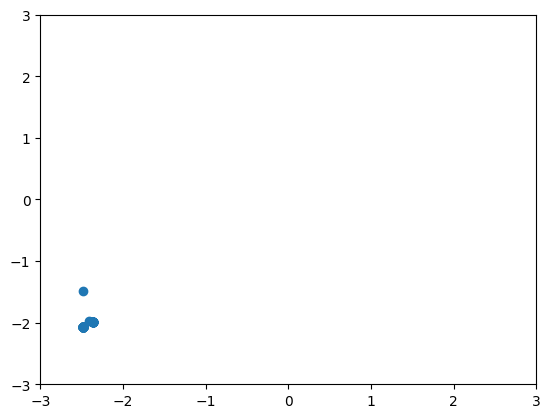

In [133]:
# plt.plot(points[labels == 1, 0], points[labels == 1, 1], 'o')
idx = 0
plt.plot(points[labels==idx, 0], points[labels==idx, 1], 'o')
plt.xlim(-3, 3)
plt.ylim(-3, 3)
plt.show()
from collections import Counter
d = Counter(actions[labels == idx].tolist())

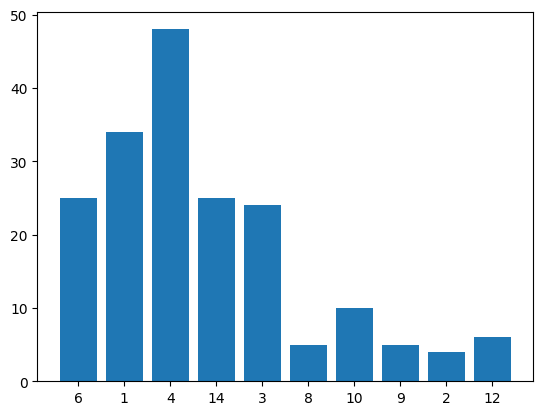

In [142]:
# plot the frequency of each action
plt.bar(list(map(lambda x: x.split('_')[1], d.keys())), d.values())
plt.show()


In [151]:
import zmq
import json
context = zmq.Context()
socket = context.socket(zmq.REQ)
socket.connect("tcp://arrakis.cs.rutgers.edu:5555")

# socket.send_string("test")

<SocketContext(connect='tcp://arrakis.cs.rutgers.edu:5555')>

In [179]:
idx = np.random.randint(0, len(all_data))
msg = json.dumps(all_data[idx]['state'])
idx
idx = 1208

In [180]:
socket.send_string(msg)
msg = socket.recv_string()
json_msg = json.loads(msg)

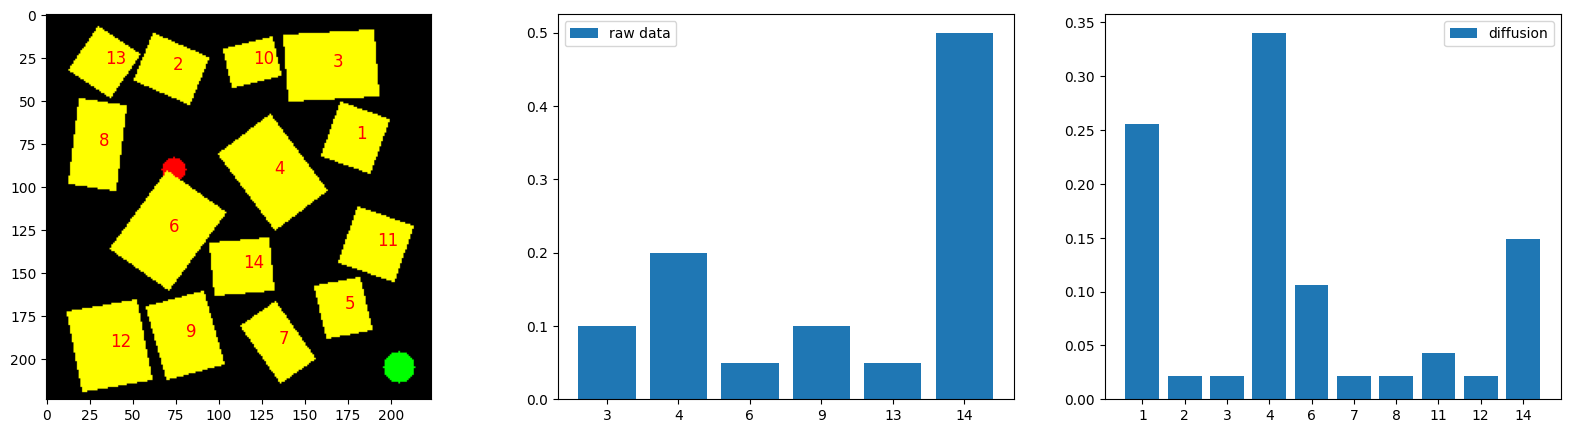

In [182]:
from collections import Counter
from json2image_converter import ImageConverter
# idx = 1
fig, axs = plt.subplots(1, 3, figsize=(20, 5))
idx = 1210
label_idx = labels[idx]
d = Counter(actions[labels == label_idx].tolist())
img_creator = ImageConverter('env_config_1')
img_data = img_creator.process_datapoint(all_data[idx]['state'])
axs[0].imshow(img_data['scene'])
# add text to the image based on object2center_px
for obj_name, center_px in img_data['obj2center_px'].items():
    axs[0].text(center_px[0], center_px[1], obj_name.split('_')[1], fontsize=12, color='red')

sorted_d = dict(sorted(d.items(), key=lambda x: int(x[0].split('_')[1]), reverse=False))
# probability of each action
probs = np.array(list(sorted_d.values()))
probs = probs / np.sum(probs)
axs[1].bar(list(map(lambda x: x.split('_')[1], sorted_d.keys())), probs, label='raw data')
axs[1].legend()

sorted_json_msg = dict(sorted(json_msg.items(), key=lambda x: int(x[0].split('_')[1]), reverse=False))
# probability of each action
probs = np.array(list(sorted_json_msg.values()))
probs = probs / np.sum(probs)
axs[2].bar(list(map(lambda x: x.split('_')[1], sorted_json_msg.keys())), probs, label='diffusion')
axs[2].legend()
# plt.show()

In [126]:
sorted_json_msg


{'obstacle_4_movable': 1, 'obstacle_13_movable': 56}